### 00

In [ ]:
%matplotlib inline

import random
from pathlib import Path

import numba
import numpy as np
import pandas as pd
import torch

from matplotlib import pyplot as plt
from scipy import sparse
from threadpoolctl import ThreadpoolController, threadpool_limits

%load_ext cython

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
CURRENT_WORKING_DIRECTORY = Path.cwd()
CURRENT_WORKING_DIRECTORY

PosixPath('/Users/anasshbat/Desktop/Uni-mac/Winter26/Projeckt_GNN/gnn_uni')

In [4]:
from pathlib import Path
csv_path = "/Users/anasshbat/Desktop/Uni-mac/Winter26/ADA/P_GNN_25/GNN_Projekt_ADA_25/main_notebook/data/00_R_tot_for_Grains_and_Rho_Ratio.csv"
grids_folder = Path("/Users/anasshbat/Desktop/Uni-mac/Winter26/ADA/P_GNN_25/GNN_Projekt_ADA_25/main_notebook/data/00_grids")

### 01- Data Laden

In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv(csv_path, comment="#", header=0)
rho_ratios = df.columns[1:].astype(float)

all_data = []
for _, row in df.iterrows():
    grain = row["Grains"]
    values = row[1:].values
    for rho, val in zip(rho_ratios, values):
        all_data.append(
            {
                "Grains": grain,
                "rho_ratio": rho,
                "R_tot_Ohm": val,
            }
        )

df_R = pd.DataFrame(all_data)
df_R = df_R.rename(
    columns={
        "Grains": "grains",
        "rho_ratio": "leitfaehigkeit",
        "R_tot_Ohm": "widerstand",
    }
)
df_R.head()

   grains  leitfaehigkeit    widerstand
0    16.0            1.00  10000.233814
1    16.0            1.26  10000.295718
2    16.0            1.60  10000.373979
3    16.0            2.02  10000.472937
4    16.0            2.56  10000.598052


In [ ]:
import numpy as np
import pandas as pd

targets = [10**2, 10**3, 10**4, 10**5]

def messung_von_leitfaehigkeit_(df, target_list):
    """Wählt je Zielwert den nächstliegenden Leitfähigkeits-Messwert aus."""
    if df.empty:
        return df

    unique_conds = df["leitfaehigkeit"].unique()
    selected_values = []
    for target in target_list:
        idx = np.abs(unique_conds - target).argmin()
        selected_values.append(unique_conds[idx])

    return df[df["leitfaehigkeit"].isin(selected_values)]

df_ml = messung_von_leitfaehigkeit_(df_R, targets)
max_grains = 500
df_ml = df_ml[df_ml["grains"] <= max_grains].copy()

df_ml["u_log"] = np.log10(df_ml["leitfaehigkeit"])
df_ml["y_log"] = np.log10(df_ml["widerstand"])

len(df_ml), df_ml["grains"].min(), df_ml["grains"].max()

Dataset bereit mit 600 Graphen.
Grains von 16.0 bis 500.0


In [ ]:
import re

grain_to_file_map = {}
for f in grids_folder.glob("*.npz"):
    match = re.search(r"grains_(\d+)", f.name)
    if match:
        grain_to_file_map[int(match.group(1))] = f

len(grain_to_file_map)

Erfolg! 930 Geometrien im Mapping registriert.
Beispiel: Grains 788 -> /Users/anasshbat/Desktop/Uni-mac/Winter26/ADA/P_GNN_25/GNN_Projekt_ADA_25/main_notebook/data/00_grids/00263_grid_101x101x101__grains_788.npz


### Mapping der Geometrien zu den Daten

In [8]:
import torch
import numpy as np
from torch_geometric.data import Data, Dataset
from gnn_tools.preprocessing import GrainsToGraph

In [ ]:
class SparseGrainDataset(Dataset):
    def __init__(self, df_ml, grain_mapping):
        super().__init__()
        self.df_ml = df_ml
        self.grain_mapping = grain_mapping
        self.cache = {}

    def len(self):
        return len(self.df_ml)

    def __len__(self):
        return self.len()

    def get(self, idx):
        row = self.df_ml.iloc[idx]
        grain_count = int(row["grains"])

        if grain_count not in self.grain_mapping:
            return Data(
                x=torch.zeros(1, 5),
                edge_index=torch.zeros(2, 1, dtype=torch.long),
                edge_attr=torch.zeros(1, 2),
                y=torch.tensor([0.0]),
            )

        file_path = self.grain_mapping[grain_count]

        if file_path not in self.cache:
            g2g = GrainsToGraph(filepath=file_path)
            node_info = g2g.node_information(as_frame=True)

            geom = node_info[[
                "volume",
                "center-coord-0",
                "center-coord-1",
                "center-coord-2",
            ]].values.copy()

            # Normalisierung der Geometrie-Features auf vergleichbare Skalen.
            vol_max = geom[:, 0].max()
            if vol_max > 0:
                geom[:, 0] /= vol_max

            for i in range(1, 4):
                c_min, c_max = geom[:, i].min(), geom[:, i].max()
                if (c_max - c_min) > 0:
                    geom[:, i] = (geom[:, i] - c_min) / (c_max - c_min)

            edge_info = g2g.edge_information(as_frame=True)
            edge_index = torch.tensor(
                edge_info[["center_node", "neighbor_node"]].values.T,
                dtype=torch.long,
            )

            edge_attr_raw = edge_info[["contact_area", "distance"]].values.copy()
            area_max = edge_attr_raw[:, 0].max()
            if area_max > 0:
                edge_attr_raw[:, 0] /= area_max

            edge_attr = torch.tensor(edge_attr_raw, dtype=torch.float)
            self.cache[file_path] = (geom, edge_index, edge_attr)

        geom, edge_index, edge_attr = self.cache[file_path]

        x = torch.tensor(
            np.hstack([np.full((geom.shape[0], 1), row["u_log"]), geom]),
            dtype=torch.float,
        )
        y = torch.tensor([row["y_log"]], dtype=torch.float)

        return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

### Baseline GNN Modell

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

class GrainGNN(nn.Module):
    def __init__(self, node_features=5, h_fea_len=128):
        super(GrainGNN, self).__init__()
        self.conv1 = GCNConv(node_features, 64)
        self.conv2 = GCNConv(64, 64)
        self.conv3 = GCNConv(64, 64)

        self.fc = nn.Sequential(
            nn.Linear(64, h_fea_len),
            nn.ReLU(),
            nn.Linear(h_fea_len, 1),
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))

        x = global_mean_pool(x, batch)
        return self.fc(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GrainGNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

Modell bereit auf cpu!


In [ ]:
def train_with_history(model, train_loader, val_loader, optimizer, criterion, epochs=50):
    history = {"train": [], "val": []}

    for _ in range(epochs):
        model.train()
        total_train_loss = 0

        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch)
            loss = criterion(out, batch.y.view(-1, 1))
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item() * batch.num_graphs

        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                out = model(batch)
                val_loss = criterion(out, batch.y.view(-1, 1))
                total_val_loss += val_loss.item() * batch.num_graphs

        train_loss = total_train_loss / len(train_loader.dataset)
        val_loss = total_val_loss / len(val_loader.dataset)

        history["train"].append(train_loss)
        history["val"].append(val_loss)

    return history

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

def analyze_model_performance(model, loader, history=None, device="cpu"):
    model.eval()

    preds_log = []
    actuals_log = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch)
            preds_log.extend(out.cpu().numpy().flatten())
            actuals_log.extend(batch.y.cpu().numpy().flatten())

    preds_log = np.array(preds_log)
    actuals_log = np.array(actuals_log)

    preds_real = 10 ** preds_log
    actuals_real = 10 ** actuals_log

    mae_log = mean_absolute_error(actuals_log, preds_log)
    mape_log = np.mean(np.abs((actuals_log - preds_log) / actuals_log)) * 100
    max_mape_log = np.max(np.abs((actuals_log - preds_log) / actuals_log)) * 100
    r2_log = r2_score(actuals_log, preds_log)

    mae_real = mean_absolute_error(actuals_real, preds_real)
    mape_real = np.mean(np.abs((actuals_real - preds_real) / actuals_real)) * 100
    max_mape_real = np.max(np.abs((actuals_real - preds_real) / actuals_real)) * 100
    r2_real = r2_score(actuals_real, preds_real)

    if history is not None:
        plt.figure(figsize=(8,5))
        plt.plot(history['train'], label="Train Loss")
        plt.plot(history['val'], label="Val Loss")
        plt.yscale("log")
        plt.xlabel("Epoch")
        plt.ylabel("MSE Loss")
        plt.title("Training History")
        plt.legend()
        plt.grid()
        plt.show()

    plt.figure(figsize=(6,6))
    plt.scatter(actuals_log, preds_log, alpha=0.5)

    min_v = min(actuals_log.min(), preds_log.min())
    max_v = max(actuals_log.max(), preds_log.max())

    plt.plot([min_v, max_v], [min_v, max_v], "--")
    plt.xlabel("True Log10(R)")
    plt.ylabel("Pred Log10(R)")
    plt.title("Parity Plot (Log Space)")
    plt.grid()
    plt.show()

    plt.figure(figsize=(6,6))
    plt.scatter(actuals_real, preds_real, alpha=0.5)

    min_v = min(actuals_real.min(), preds_real.min())
    max_v = max(actuals_real.max(), preds_real.max())

    plt.plot([min_v, max_v], [min_v, max_v], "--")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("True R")
    plt.ylabel("Pred R")
    plt.title("Parity Plot (Real Space)")
    plt.grid()
    plt.show()

    return {
        "mae_log": mae_log,
        "mape_log": mape_log,
        "max_mape_log": max_mape_log,
        "r2_log": r2_log,
        "mae_real": mae_real,
        "mape_real": mape_real,
        "max_mape_real": max_mape_real,
        "r2_real": r2_real
    }

In [14]:
def predict_on_loader(model, loader, device):
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch)
            y_true.append(batch.y.cpu())
            y_pred.append(out.cpu())
    y_true = torch.cat(y_true).numpy()
    y_pred = torch.cat(y_pred).numpy()
    return y_true, y_pred

def plot_true_vs_pred(y_true, y_pred, title="True vs Predicted"):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.7)
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()],
             'r--', lw=2)
    plt.xlabel("True values")
    plt.ylabel("Predicted values")
    plt.title(title)
    plt.grid(True)
    plt.show()

### Experimentelle Trainingsschleife (nur 1 Epoche zum Testen)

In [15]:
from dataclasses import dataclass

@dataclass
class ExperimentConfig:
    # Training
    epochs: int = 50
    batch_size: int = 32
    lr: float = 1e-3
    
    # Model
    node_features: int = 5
    hidden_dim: int = 128
    
    # Dataset
    max_grains: int = 500
    targets: tuple = (1e2, 1e3, 1e4, 1e5)
    
    # Seed
    seed: int = 42
    
    # Logging
    experiment_name: str = "baseline_gnn"


In [ ]:
def setup_experiment(cfg: ExperimentConfig):
    seed_everything(cfg.seed)

    model = GrainGNN(
        node_features=cfg.node_features,
        h_fea_len=cfg.hidden_dim,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    criterion = nn.MSELoss()

    return model, optimizer, criterion

In [17]:
import os
import json

def get_exp_folder(cfg: ExperimentConfig):
    base_dir = "./exps"
    exp_dir = os.path.join(base_dir, cfg.experiment_name)
    os.makedirs(exp_dir, exist_ok=True)
    return exp_dir

In [ ]:
def build_dataset(cfg: ExperimentConfig):
    df_ml_local = df_R.copy()

    available_grains = set(grain_to_file_map.keys())
    df_ml_local = df_ml_local[df_ml_local["grains"].isin(available_grains)].copy()
    df_ml_local = df_ml_local[df_ml_local["grains"] <= cfg.max_grains].copy()

    df_ml_local["u_log"] = np.log10(df_ml_local["leitfaehigkeit"])
    df_ml_local["y_log"] = np.log10(df_ml_local["widerstand"])

    return SparseGrainDataset(df_ml_local, grain_to_file_map)

In [20]:
from torch_geometric.loader import DataLoader
from torch.utils.data import random_split 
def build_loaders(dataset, cfg: ExperimentConfig):
    n_total = len(dataset)
    train_size = int(0.7 * n_total)
    val_size = int(0.15 * n_total)
    test_size = n_total - train_size - val_size
    
    train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])
    
    train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader

In [ ]:
def main_train(cfg: ExperimentConfig):
    model, optimizer, criterion = setup_experiment(cfg)

    dataset = build_dataset(cfg)
    train_loader, val_loader, test_loader = build_loaders(dataset, cfg)

    history = train_with_history(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        epochs=cfg.epochs,
    )

    exp_dir = get_exp_folder(cfg)

    cfg_path = os.path.join(exp_dir, "config.json")
    with open(cfg_path, "w") as f:
        json.dump(cfg.__dict__, f, indent=4)

    model_path = os.path.join(exp_dir, "best_model.pth")
    torch.save(model.state_dict(), model_path)

    history_path = os.path.join(exp_dir, "training_history.csv")
    import pandas as pd
    pd.DataFrame(history).to_csv(history_path, index=False)

    return model, history

In [22]:
cfg = ExperimentConfig(
    epochs=200,
    batch_size=32,
    lr=1e-3,
    hidden_dim=128,
    experiment_name="01_exp_baseM_200Ep"  # 
)

model, history = main_train(cfg)



===== Experiment: 01_exp_baseM_200Ep =====
Dataset enthält 9300 Graphen.
Verfügbare Grain-Typen: 930
Leitfähigkeiten: [1.0, 1.26, 1.6, 2.02, 2.56, 3.24, 4.0, 4.09, 5.18, 6.55, 7.0, 8.29, 10.0, 10.5, 13.3, 16.8, 21.2, 26.8, 33.9, 40.0, 42.9, 54.3, 68.7, 70.0, 86.9, 100.0, 110.0, 139.0, 176.0, 222.0, 281.0, 356.0, 400.0, 450.0, 569.0, 700.0, 720.0, 910.0, 1000.0, 1150.0, 1460.0, 1840.0, 2330.0, 2950.0, 3730.0, 4000.0, 4710.0, 5960.0, 7000.0, 7540.0, 9540.0, 10000.0, 12100.0, 15300.0, 19300.0, 24400.0, 30900.0, 39100.0, 49400.0, 62500.0, 79100.0, 100000.0]
Epoch 000 | Train MSE: 1.721324 | Val MSE: 0.006497
Epoch 005 | Train MSE: 0.003044 | Val MSE: 0.002435
Epoch 010 | Train MSE: 0.001224 | Val MSE: 0.001343
Epoch 015 | Train MSE: 0.000678 | Val MSE: 0.000564
Epoch 020 | Train MSE: 0.000618 | Val MSE: 0.000622
Epoch 025 | Train MSE: 0.000696 | Val MSE: 0.000475
Epoch 030 | Train MSE: 0.000556 | Val MSE: 0.000605
Epoch 035 | Train MSE: 0.000906 | Val MSE: 0.000656
Epoch 040 | Train MSE: 

Creating val_loader from build_dataset...
Dataset enthält 9300 Graphen.
Verfügbare Grain-Typen: 930
Leitfähigkeiten: [1.0, 1.26, 1.6, 2.02, 2.56, 3.24, 4.0, 4.09, 5.18, 6.55, 7.0, 8.29, 10.0, 10.5, 13.3, 16.8, 21.2, 26.8, 33.9, 40.0, 42.9, 54.3, 68.7, 70.0, 86.9, 100.0, 110.0, 139.0, 176.0, 222.0, 281.0, 356.0, 400.0, 450.0, 569.0, 700.0, 720.0, 910.0, 1000.0, 1150.0, 1460.0, 1840.0, 2330.0, 2950.0, 3730.0, 4000.0, 4710.0, 5960.0, 7000.0, 7540.0, 9540.0, 10000.0, 12100.0, 15300.0, 19300.0, 24400.0, 30900.0, 39100.0, 49400.0, 62500.0, 79100.0, 100000.0]
val_loader created with 1395 samples

===== LOG SPACE METRICS =====
MAE Log      : 0.004467
MAPE Log (%) : 0.1076
MAX MAPE Log : 0.9630
R² Log       : 0.997778

===== REAL SPACE METRICS =====
MAE Real      : 170.810883
MAPE Real (%) : 1.0312
MAX MAPE Real : 10.2492
R² Real       : 0.996155


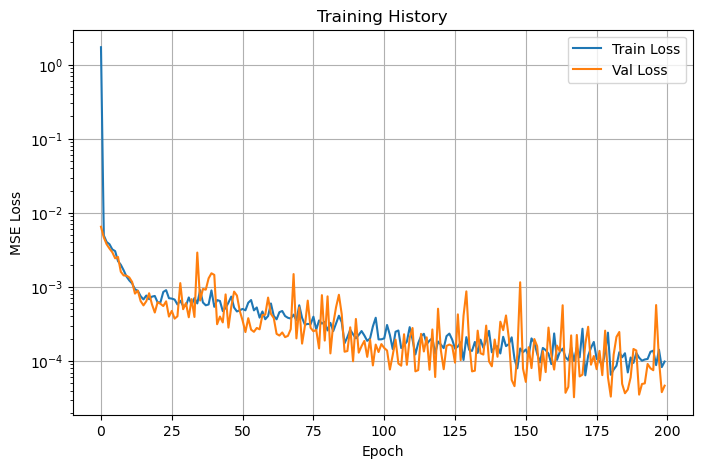

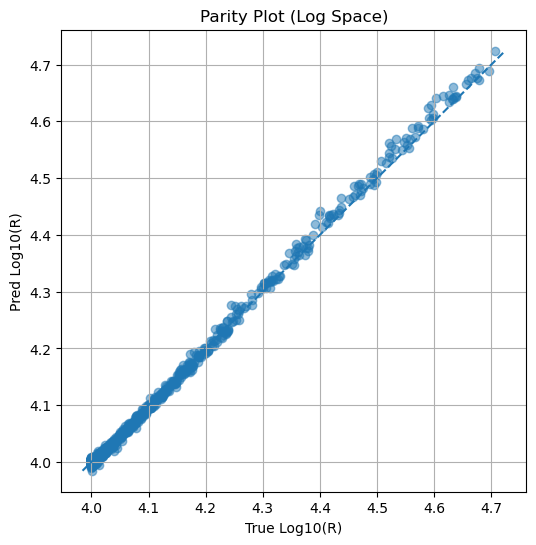

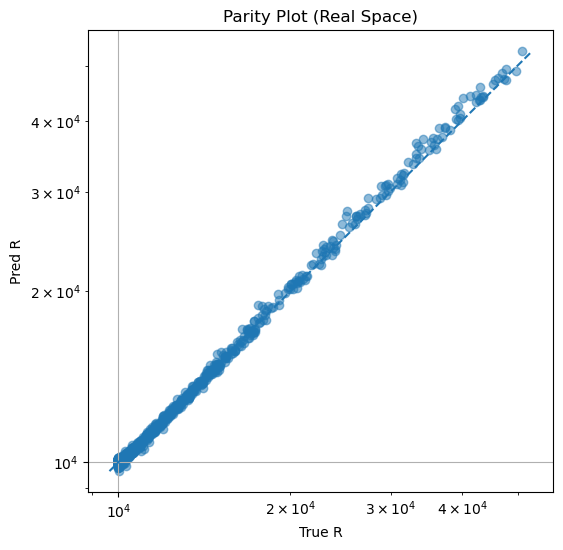

In [ ]:
if "val_loader" not in locals():
    dataset = build_dataset(cfg)
    _, val_loader, _ = build_loaders(dataset, cfg)

metrics = analyze_model_performance(model, val_loader, history, device=device)

### Load 

In [ ]:
exp_path = '/Users/anasshbat/Desktop/Uni-mac/Winter26/Projeckt_GNN/gnn_uni/exps'
listdir = os.listdir(exp_path)
listdir

['exp_model_all_leitfaehigkeit&200_Epoch', '02_baseline_gnn_v2', '.DS_Store', 'exp_model_u_nach_conv', 'exp_optimized_2', 'Test', 'exp_test', 'exp_grain_baseline', 'exp_modelB__G500_ALL_leits', 'exp_model_all_leitfaehigkeit', 'exp_model_v1', 'exp_model_4L_500_50E-4leitfaehigkeit', '01_exp_baseM_200Ep', 'Test_Experiment', 'exp_modelB__G5000_L4', 'exp_modelB__Gg500_4', 'exp_optimized', 'exp_model_4L_Gk2000_50E', 'exp_modelB__G2000_L4', 'exp_model_u_nach_conv_200_epochen']


In [27]:
def path_modelle(model_name):
    return os.path.join(exp_path, model_name, "best_model.pth")

## Modell laden analyze_model_performance auswerten


===== LOG SPACE METRICS =====
MAE Log      : 0.004626
MAPE Log (%) : 0.1118
MAX MAPE Log : 0.9630
R² Log       : 0.997657

===== REAL SPACE METRICS =====
MAE Real      : 169.391907
MAPE Real (%) : 1.0668
MAX MAPE Real : 10.2555
R² Real       : 0.996454


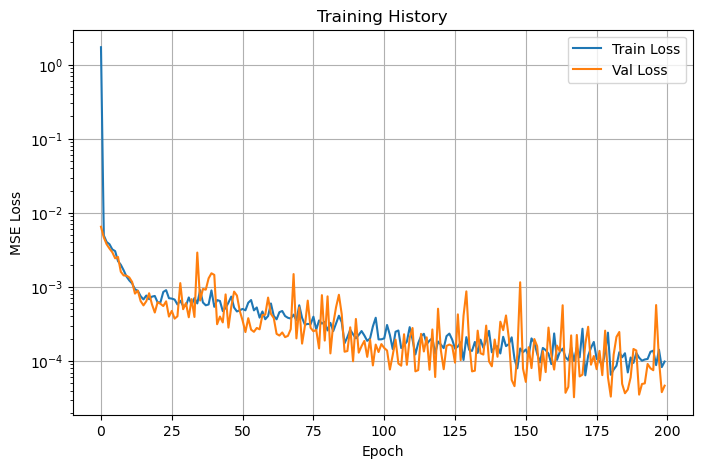

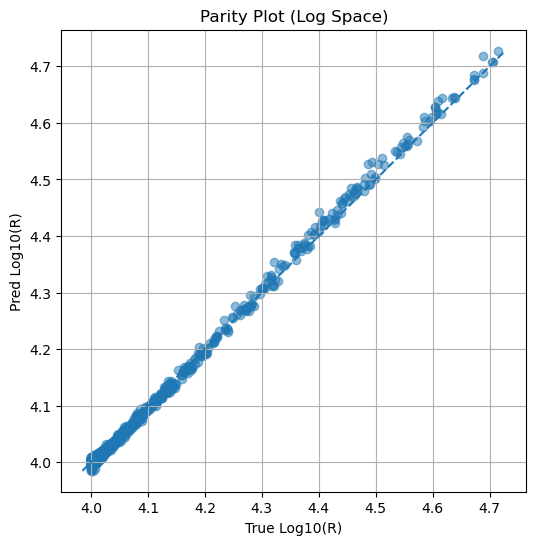

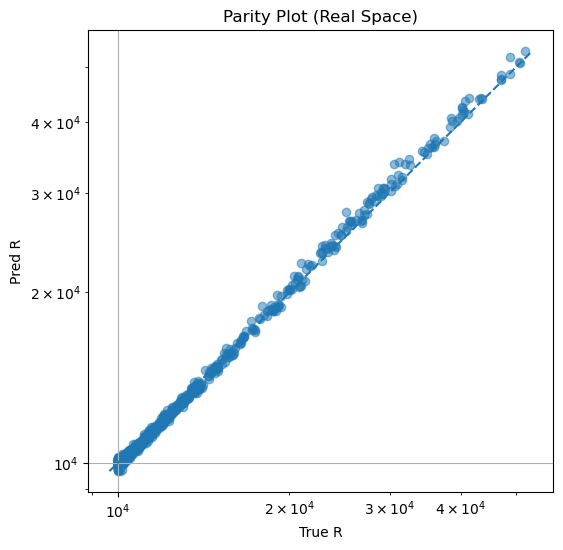

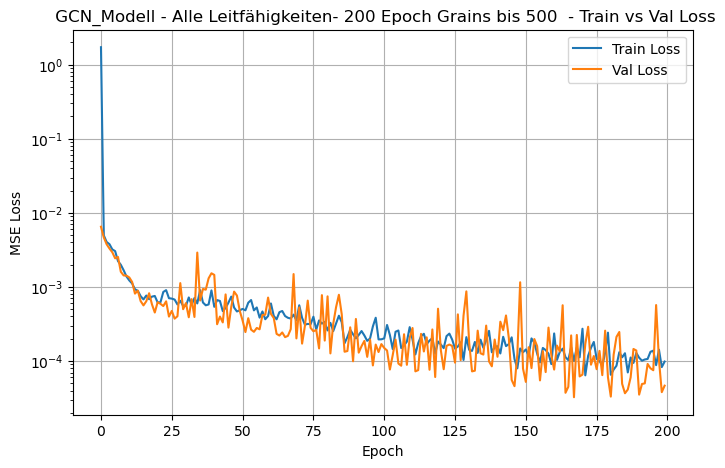

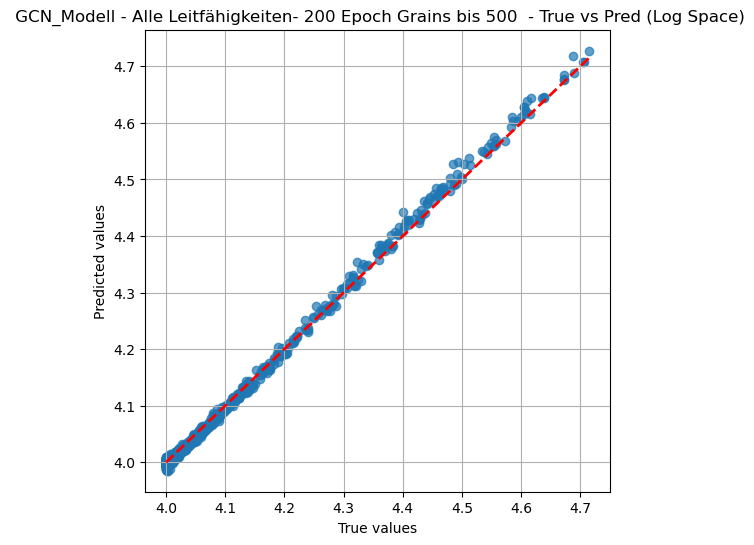

{'mae_log': 0.004626244772225618,
 'mape_log': 0.1117633655667305,
 'max_mape_log': 0.9630375541746616,
 'r2_log': 0.9976574182510376,
 'mae_real': 169.39190673828125,
 'mape_real': 1.066769938915968,
 'max_mape_real': 10.255517065525055,
 'r2_real': 0.9964542984962463}

In [ ]:
EXP_NAME = "exp_model_all_leitfaehigkeit&200_Epoch"
PLOT_TITLE_PREFIX = " GCN_Modell - Alle Leitfaehigkeiten- 200 Epoch Grains bis 500 "

required = [
    "ExperimentConfig",
    "GrainGNN",
    "build_dataset",
    "build_loaders",
    "analyze_model_performance",
    "predict_on_loader",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise NameError(
        "Diese Definitionen fehlen im Kernel: "
        + ", ".join(missing)
        + ".\nBitte zuerst die Setup-/Definitionszellen oben ausfuehren."
    )

exp_dir = os.path.join("./exps", EXP_NAME)
cfg_path = os.path.join(exp_dir, "config.json")
model_path = os.path.join(exp_dir, "best_model.pth")
history_path = os.path.join(exp_dir, "training_history.csv")

if not os.path.exists(cfg_path):
    raise FileNotFoundError(f"config.json nicht gefunden: {cfg_path}")
if not os.path.exists(model_path):
    raise FileNotFoundError(f"best_model.pth nicht gefunden: {model_path}")

with open(cfg_path, "r") as f:
    cfg_loaded = ExperimentConfig(**json.load(f))

loaded_model = GrainGNN(
    node_features=cfg_loaded.node_features,
    h_fea_len=cfg_loaded.hidden_dim,
).to(device)

# `weights_only=True` reduziert Pickle-Risiken in neueren Torch-Versionen.
try:
    state_dict = torch.load(model_path, map_location=device, weights_only=True)
except TypeError:
    state_dict = torch.load(model_path, map_location=device)

loaded_model.load_state_dict(state_dict)
loaded_model.eval()

if "test_loader" not in globals() or test_loader is None:
    dataset = build_dataset(cfg_loaded)
    _, _, test_loader = build_loaders(dataset, cfg_loaded)

history_loaded = None
if os.path.exists(history_path):
    history_df = pd.read_csv(history_path)
    if {"train", "val"}.issubset(history_df.columns):
        history_loaded = {
            "train": history_df["train"].tolist(),
            "val": history_df["val"].tolist(),
        }

metrics_test = analyze_model_performance(
    loaded_model,
    test_loader,
    history=history_loaded,
    device=device,
 )

if history_loaded is not None:
    plt.figure(figsize=(8, 5))
    plt.plot(history_loaded["train"], label="Train Loss")
    plt.plot(history_loaded["val"], label="Val Loss")
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(f"{PLOT_TITLE_PREFIX} - Train vs Val Loss")
    plt.legend()
    plt.grid()
    plt.show()

true_log, pred_log = predict_on_loader(loaded_model, test_loader, device)
plot_true_vs_pred(true_log, pred_log, title=f"{PLOT_TITLE_PREFIX} - True vs Pred (Log Space)")

metrics_test